# Multi-Timescale Training Notebook

- `merged30m.csv` -> encoder-only Transformer branch (`window=240`)
- `merged1d.csv` -> small GRU branch (`window=5`)
- `finalLabels.csv` -> soft labels aligned on 30m `time`
- Daily features are lagged by one full day so intraday targets only see the latest completed 1d bar.


In [60]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [61]:
from pathlib import Path
import os
import random
import copy
import math

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# -------------------- Paths --------------------
# Paths updated to point to Google Drive
BASE_DRIVE_PATH = '/content/drive/MyDrive/BTC/'
DATA_30M_PATH = os.path.join(BASE_DRIVE_PATH, 'merged30m.csv')
DATA_1D_PATH = os.path.join(BASE_DRIVE_PATH, 'merged1d.csv')
LABELS_PATH = os.path.join(BASE_DRIVE_PATH, 'finalLabels.csv')
MODEL_SAVE_PATH = 'multi_timescale_transformer_gru_80_10_10.pt'

# -------------------- Seed / Determinism --------------------
SEED = 42

# -------------------- Sequence / Split Hyperparameters --------------------
WINDOW_SIZE_30M = 240
WINDOW_SIZE_1D = 5
TRAIN_RATIO = 0.80
VAL_RATIO = 0.10
TEST_RATIO = 0.10
TRAIN_STRIDE = 10
BATCH_SIZE = 64
USE_VALIDATION = True
EVAL_SPLIT = 'test'
EVAL_SPLIT_DISPLAY = 'Test'
FORCED_STOP_EPOCH = None

# -------------------- Training Hyperparameters --------------------
NUM_EPOCHS = 60
LEARNING_RATE = 5e-4
WEIGHT_DECAY = 5e-4
PATIENCE = 25
ENTROPY_REG_WEIGHT = 0.85

# -------------------- 30m Normalization Hyperparameters --------------------
LEVEL_WINDOW_30M = 48 * 60
FLOW_ACTIVITY_WINDOW_30M = 48 * 60
CVD_DETREND_WINDOW_30M = 48 * 14

# -------------------- 1d Normalization Hyperparameters --------------------
LEVEL_WINDOW_1D = 60

# -------------------- Trade Decision Hyperparameters --------------------
TRADE_RULE_MAX_FLAT_PROB = 0.7
TRADE_RULE_SIDE_RATIO = 2

# -------------------- Alignment Hyperparameters --------------------
DAILY_FEATURE_LAG_DAYS = 1  # use only the last completed daily bar for each 30m target

# -------------------- Transformer Hyperparameters --------------------
D_MODEL = 16
NHEAD = 4
NUM_LAYERS = 1
DIM_FEEDFORWARD = 32
DROPOUT = 0.3
MAX_POS_EMBED_LEN = 4096

# -------------------- GRU Hyperparameters --------------------
GRU_HIDDEN_DIM = 8
GRU_NUM_LAYERS = 1
GRU_DROPOUT = 0.25

# -------------------- Fusion Head Hyperparameters --------------------
FUSION_HIDDEN_DIM = 24

CLASS_NAMES = ['up', 'flat', 'down']
TARGET_COLS = [f'p_{name}' for name in CLASS_NAMES]
OUTPUT_DIM = len(TARGET_COLS)

ratio_sum = TRAIN_RATIO + VAL_RATIO + TEST_RATIO
if not math.isclose(ratio_sum, 1.0, rel_tol=0.0, abs_tol=1e-9):
    raise ValueError(f'TRAIN_RATIO + VAL_RATIO + TEST_RATIO must equal 1.0, got {ratio_sum:.12f}')


def set_seed(seed: int = 42) -> None:
    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    try:
        torch.use_deterministic_algorithms(True)
    except Exception as e:
        print(f'Warning: deterministic algorithms could not be fully enabled: {e}')


set_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)


Device: cuda


In [62]:
# 1) Data load + 30m-label / 1d-anchor alignment
path_30m = Path(DATA_30M_PATH)
path_1d = Path(DATA_1D_PATH)
path_labels = Path(LABELS_PATH)

for path in [path_30m, path_1d, path_labels]:
    if not path.exists():
        raise FileNotFoundError(f'Missing required input file: {path}')

df_30m = pd.read_csv(path_30m)
df_1d = pd.read_csv(path_1d)
labels = pd.read_csv(path_labels)

required_30m_cols = ['time']
required_1d_cols = ['Date']
required_label_cols = ['time'] + TARGET_COLS

missing_30m = [c for c in required_30m_cols if c not in df_30m.columns]
missing_1d = [c for c in required_1d_cols if c not in df_1d.columns]
missing_labels = [c for c in required_label_cols if c not in labels.columns]
if missing_30m:
    raise KeyError(f'Missing required 30m columns: {missing_30m}')
if missing_1d:
    raise KeyError(f'Missing required 1d columns: {missing_1d}')
if missing_labels:
    raise KeyError(f'Missing required label columns: {missing_labels}')

df_30m['time'] = pd.to_datetime(df_30m['time'], errors='coerce')
df_1d['Date'] = pd.to_datetime(df_1d['Date'], errors='coerce').dt.normalize()
labels['time'] = pd.to_datetime(labels['time'], errors='coerce')

df_30m = df_30m.dropna(subset=['time']).sort_values('time').reset_index(drop=True)
df_1d = df_1d.dropna(subset=['Date']).sort_values('Date').reset_index(drop=True)
labels = labels.dropna(subset=['time']).sort_values('time').reset_index(drop=True)

if df_30m['time'].duplicated().any():
    raise ValueError('merged30m.csv contains duplicate timestamps.')
if df_1d['Date'].duplicated().any():
    raise ValueError('merged1d.csv contains duplicate dates.')
if labels['time'].duplicated().any():
    raise ValueError('finalLabels.csv contains duplicate timestamps.')

prob_sums = labels[TARGET_COLS].sum(axis=1)
if not np.allclose(prob_sums.to_numpy(dtype=np.float64), 1.0, atol=1e-6):
    raise ValueError('Label probabilities must sum to 1.0 for every row.')

df_30m['raw_30m_idx'] = np.arange(len(df_30m), dtype=np.int64)
feature_cols_30m = [c for c in df_30m.columns if c not in {'time', 'raw_30m_idx'}]
X30_raw_df = df_30m[feature_cols_30m].select_dtypes(include=[np.number]).copy()
feature_cols_30m = X30_raw_df.columns.tolist()

df_1d['daily_row_idx'] = np.arange(len(df_1d), dtype=np.int64)
df_1d['available_time'] = df_1d['Date'] + pd.to_timedelta(DAILY_FEATURE_LAG_DAYS, unit='D')
feature_cols_1d = [c for c in df_1d.columns if c not in {'Date', 'daily_row_idx', 'available_time'}]
X1d_raw_df = df_1d[feature_cols_1d].select_dtypes(include=[np.number]).copy()
feature_cols_1d = X1d_raw_df.columns.tolist()

label_merge_cols = ['time', *TARGET_COLS]
if 'hard_label' in labels.columns:
    label_merge_cols.append('hard_label')

sample_df = df_30m[['time', 'raw_30m_idx', *feature_cols_30m]].merge(
    labels[label_merge_cols],
    on='time',
    how='inner',
    validate='one_to_one',
)

sample_df = pd.merge_asof(
    sample_df.sort_values('time'),
    df_1d[['available_time', 'daily_row_idx']].sort_values('available_time'),
    left_on='time',
    right_on='available_time',
    direction='backward',
)

missing_daily_anchor = int(sample_df['daily_row_idx'].isna().sum())
if missing_daily_anchor:
    print('Dropping samples without a completed daily anchor:', missing_daily_anchor)

sample_df = sample_df.dropna(subset=['daily_row_idx']).reset_index(drop=True)
sample_df['daily_row_idx'] = sample_df['daily_row_idx'].astype(np.int64)

n_samples = len(sample_df)
if n_samples == 0:
    raise ValueError('No aligned samples remain after label and daily-anchor joins.')

train_end = int(n_samples * TRAIN_RATIO)
val_end = train_end + int(n_samples * VAL_RATIO)

split_labels = np.full(n_samples, 'unused', dtype=object)
split_labels[:train_end] = 'train'

cursor = train_end
if VAL_RATIO > 0:
    split_labels[cursor:val_end] = 'val'
    cursor = val_end
if TEST_RATIO > 0:
    split_labels[cursor:] = 'test'
else:
    fallback_split = 'val' if VAL_RATIO > 0 else 'train'
    split_labels[cursor:] = fallback_split

sample_df['split'] = split_labels

train_sample_mask = sample_df['split'] == 'train'
val_sample_mask = sample_df['split'] == 'val'
test_sample_mask = sample_df['split'] == 'test'

required_splits = ['train']
if VAL_RATIO > 0:
    required_splits.append('val')
if TEST_RATIO > 0:
    required_splits.append('test')

for split_name in required_splits:
    if not (sample_df['split'] == split_name).any():
        raise ValueError(f'{split_name} split is empty after chronological splitting.')

max_train_30m_idx = int(sample_df.loc[train_sample_mask, 'raw_30m_idx'].max())
max_train_1d_idx = int(sample_df.loc[train_sample_mask, 'daily_row_idx'].max())

split_counts = sample_df['split'].value_counts().reindex(['train', 'val', 'test'], fill_value=0)

print('30m rows:', len(df_30m), '| 1d rows:', len(df_1d), '| labeled samples:', len(sample_df))
print('Train/Val/Test samples:', int(split_counts['train']), int(split_counts['val']), int(split_counts['test']))
print('30m feature count:', len(feature_cols_30m))
print('1d feature count:', len(feature_cols_1d))
print('Sample time range:', sample_df['time'].min(), '->', sample_df['time'].max())
print('Daily anchor index range:', int(sample_df['daily_row_idx'].min()), '->', int(sample_df['daily_row_idx'].max()))
print('Example aligned rows:')
display(sample_df[['time', 'daily_row_idx', 'split', *TARGET_COLS]].head(5))


30m rows: 102094 | 1d rows: 2130 | labeled samples: 102078
Train/Val/Test samples: 81662 10207 10209
30m feature count: 69
1d feature count: 9
Sample time range: 2020-06-02 00:00:00 -> 2026-03-31 14:30:00
Daily anchor index range: 0 -> 2128
Example aligned rows:


,time,daily_row_idx,split,p_up,p_flat,p_down
0,2020-06-02 00:00:00,0,train,0.114783,0.554637,0.330580
1,2020-06-02 00:30:00,0,train,0.145379,0.647343,0.207279
2,2020-06-02 01:00:00,0,train,0.165534,0.684849,0.149617
3,2020-06-02 01:30:00,0,train,0.144947,0.644938,0.210115
4,2020-06-02 02:00:00,0,train,0.154111,0.695917,0.149972


In [63]:
# 2) Branch-specific normalization
def dedupe_preserve_order(column_names):
    return list(dict.fromkeys(column_names))


def trailing_mean_past_only(series: pd.Series, window: int) -> pd.Series:
    return series.shift(1).rolling(window=window, min_periods=1).mean()


def infer_activity_base_col(col_name: str, available_columns) -> str | None:
    prefix = col_name.rsplit('_', 1)[0]
    candidates = [
        f'{prefix}_quote_volume',
        f'{prefix}_volume',
        f'{prefix}_count',
    ]
    for candidate in candidates:
        if candidate in available_columns:
            return candidate
    return None


def infer_atr_base_col(col_name: str, available_columns) -> str | None:
    suffix_map = {
        '_macd_signal': '_atr_14',
        '_macd_hist': '_atr_14',
        '_macd': '_atr_14',
    }
    for suffix, replacement in suffix_map.items():
        if col_name.endswith(suffix):
            candidate = f'{col_name[:-len(suffix)]}{replacement}'
            if candidate in available_columns:
                return candidate
    return None


def resolve_30m_feature_groups(columns):
    price_cols = [c for c in columns if c.endswith(('_open', '_high', '_low', '_close'))]
    level_cols = [
        c for c in columns
        if c.endswith(('_quote_volume', '_count')) or c == 'CME_volume' or c.endswith('_atr_14')
    ]
    bounded_cols = [c for c in columns if c.endswith('_rsi_14') or c.endswith('_bb_position_20_2')]
    macd_cols = [c for c in columns if c.endswith('_macd') or c.endswith('_macd_signal') or c.endswith('_macd_hist')]
    delta_cols = [c for c in columns if c.endswith('_delta')]
    cvd_cols = [c for c in columns if c.endswith('_cvd')]
    funding_cols = [c for c in columns if 'funding_rate' in c.lower()]

    reserved = set(price_cols + level_cols + bounded_cols + macd_cols + delta_cols + cvd_cols + funding_cols)
    other_cols = [c for c in columns if c not in reserved]

    groups = {
        'price_cols': dedupe_preserve_order(price_cols),
        'level_cols': dedupe_preserve_order(level_cols),
        'bounded_cols': dedupe_preserve_order(bounded_cols),
        'macd_cols': dedupe_preserve_order(macd_cols),
        'delta_cols': dedupe_preserve_order(delta_cols),
        'cvd_cols': dedupe_preserve_order(cvd_cols),
        'funding_cols': dedupe_preserve_order(funding_cols),
        'other_cols': dedupe_preserve_order(other_cols),
    }
    groups['standard_scale_cols'] = dedupe_preserve_order(
        groups['price_cols']
        + groups['level_cols']
        + groups['bounded_cols']
        + groups['macd_cols']
        + groups['delta_cols']
        + groups['cvd_cols']
        + groups['funding_cols']
        + groups['other_cols']
    )
    return groups


def resolve_1d_feature_groups(columns):
    level_names = {'fed_net_liquidity', 'tga', 'rrp', 'oi_open', 'oi_high', 'oi_low', 'oi_close'}
    bounded_names = {'long_ratio', 'short_ratio'}

    level_cols = [c for c in columns if c in level_names]
    bounded_cols = [c for c in columns if c in bounded_names]
    other_cols = [c for c in columns if c not in set(level_cols + bounded_cols)]

    groups = {
        'level_cols': dedupe_preserve_order(level_cols),
        'bounded_cols': dedupe_preserve_order(bounded_cols),
        'other_cols': dedupe_preserve_order(other_cols),
    }
    groups['standard_scale_cols'] = dedupe_preserve_order(
        groups['level_cols'] + groups['bounded_cols'] + groups['other_cols']
    )
    return groups


def normalize_30m_frame(raw_df: pd.DataFrame, groups: dict) -> pd.DataFrame:
    numeric_df = raw_df.apply(pd.to_numeric, errors='coerce')
    norm_df = numeric_df.copy()

    for col in groups['price_cols']:
        prev = numeric_df[col].shift(1)
        norm_df[col] = np.log(numeric_df[col] / prev)

    for col in groups['level_cols']:
        baseline = trailing_mean_past_only(numeric_df[col], LEVEL_WINDOW_30M).replace(0, np.nan)
        norm_df[col] = numeric_df[col] / baseline

    for col in groups['macd_cols']:
        atr_base_col = infer_atr_base_col(col, numeric_df.columns)
        if atr_base_col is None:
            continue
        atr_base = numeric_df[atr_base_col].replace(0, np.nan)
        norm_df[col] = numeric_df[col] / atr_base

    for col in groups['delta_cols']:
        activity_col = infer_activity_base_col(col, numeric_df.columns)
        activity_source = numeric_df[activity_col].abs() if activity_col is not None else numeric_df[col].abs()
        activity_baseline = trailing_mean_past_only(activity_source, FLOW_ACTIVITY_WINDOW_30M).replace(0, np.nan)
        norm_df[col] = numeric_df[col] / activity_baseline

    for col in groups['cvd_cols']:
        activity_col = infer_activity_base_col(col, numeric_df.columns)
        activity_source = numeric_df[activity_col].abs() if activity_col is not None else numeric_df[col].abs()
        activity_baseline = trailing_mean_past_only(activity_source, FLOW_ACTIVITY_WINDOW_30M).replace(0, np.nan)
        cvd_trend = trailing_mean_past_only(numeric_df[col], CVD_DETREND_WINDOW_30M)
        cvd_residual = numeric_df[col] - cvd_trend
        norm_df[col] = cvd_residual / activity_baseline

    norm_df = norm_df.replace([np.inf, -np.inf], np.nan)
    return norm_df


def normalize_1d_frame(raw_df: pd.DataFrame, groups: dict) -> pd.DataFrame:
    numeric_df = raw_df.apply(pd.to_numeric, errors='coerce')
    norm_df = numeric_df.copy()

    for col in groups['level_cols']:
        baseline = trailing_mean_past_only(numeric_df[col], LEVEL_WINDOW_1D).replace(0, np.nan)
        norm_df[col] = numeric_df[col] / baseline

    norm_df = norm_df.replace([np.inf, -np.inf], np.nan)
    return norm_df


groups_30m = resolve_30m_feature_groups(feature_cols_30m)
groups_1d = resolve_1d_feature_groups(feature_cols_1d)

print('30m groups:')
for key, value in groups_30m.items():
    print(f'  {key}:', value)

print('\n1d groups:')
for key, value in groups_1d.items():
    print(f'  {key}:', value)

X30_norm_df = normalize_30m_frame(X30_raw_df, groups_30m)
X1d_norm_df = normalize_1d_frame(X1d_raw_df, groups_1d)

X30_scaled_df = X30_norm_df.copy()
X1d_scaled_df = X1d_norm_df.copy()

train_row_mask_30m = np.arange(len(X30_norm_df)) <= max_train_30m_idx
train_row_mask_1d = np.arange(len(X1d_norm_df)) <= max_train_1d_idx

scaler_30m = StandardScaler()
scaler_1d = StandardScaler()

fit_mask_30m = train_row_mask_30m & X30_norm_df[groups_30m['standard_scale_cols']].notna().all(axis=1).to_numpy()
fit_mask_1d = train_row_mask_1d & X1d_norm_df[groups_1d['standard_scale_cols']].notna().all(axis=1).to_numpy()

if not fit_mask_30m.any():
    raise ValueError('No valid 30m training rows available to fit the scaler.')
if not fit_mask_1d.any():
    raise ValueError('No valid 1d training rows available to fit the scaler.')

scaler_30m.fit(X30_norm_df.loc[fit_mask_30m, groups_30m['standard_scale_cols']])
scaler_1d.fit(X1d_norm_df.loc[fit_mask_1d, groups_1d['standard_scale_cols']])

transform_mask_30m = X30_norm_df[groups_30m['standard_scale_cols']].notna().all(axis=1).to_numpy()
transform_mask_1d = X1d_norm_df[groups_1d['standard_scale_cols']].notna().all(axis=1).to_numpy()

X30_scaled_df.loc[transform_mask_30m, groups_30m['standard_scale_cols']] = scaler_30m.transform(
    X30_norm_df.loc[transform_mask_30m, groups_30m['standard_scale_cols']]
)
X1d_scaled_df.loc[transform_mask_1d, groups_1d['standard_scale_cols']] = scaler_1d.transform(
    X1d_norm_df.loc[transform_mask_1d, groups_1d['standard_scale_cols']]
)

print('30m rows with any NaN after normalization:', int(X30_scaled_df.isna().any(axis=1).sum()))
print('1d rows with any NaN after normalization:', int(X1d_scaled_df.isna().any(axis=1).sum()))
print('30m scaler fit rows:', int(fit_mask_30m.sum()))
print('1d scaler fit rows:', int(fit_mask_1d.sum()))


30m groups:
  price_cols: ['coinbase_open', 'coinbase_high', 'coinbase_low', 'coinbase_close', 'binanceFutures_open', 'binanceFutures_high', 'binanceFutures_low', 'binanceFutures_close', 'binanceSpot_open', 'binanceSpot_high', 'binanceSpot_low', 'binanceSpot_close', 'bybit_open', 'bybit_high', 'bybit_low', 'bybit_close', 'CME_open', 'CME_high', 'CME_low', 'CME_close']
  level_cols: ['coinbase_quote_volume', 'coinbase_atr_14', 'binanceFutures_quote_volume', 'binanceFutures_count', 'binanceFutures_atr_14', 'binanceSpot_quote_volume', 'binanceSpot_count', 'binanceSpot_atr_14', 'bybit_quote_volume', 'bybit_count', 'bybit_atr_14', 'CME_volume', 'CME_count', 'CME_atr_14']
  bounded_cols: ['coinbase_rsi_14', 'coinbase_bb_position_20_2', 'binanceFutures_rsi_14', 'binanceFutures_bb_position_20_2', 'binanceSpot_rsi_14', 'binanceSpot_bb_position_20_2', 'bybit_rsi_14', 'bybit_bb_position_20_2', 'CME_rsi_14', 'CME_bb_position_20_2']
  macd_cols: ['coinbase_macd', 'coinbase_macd_signal', 'coinbase_m

In [64]:
# 3) Dual-window builder
def build_dual_windows(sample_df, x30_df, x1d_df, window_30m, window_1d):
    x30_arr = x30_df.to_numpy(dtype=np.float32)
    x1d_arr = x1d_df.to_numpy(dtype=np.float32)
    y_arr = sample_df[TARGET_COLS].to_numpy(dtype=np.float32)
    hard_available = 'hard_label' in sample_df.columns
    hard_arr = sample_df['hard_label'].to_numpy(dtype=object) if hard_available else None

    x30_windows = []
    x1d_windows = []
    y_targets = []
    target_times = []
    split_out = []
    hard_out = []

    dropped_short_30m = 0
    dropped_short_1d = 0
    dropped_nan = 0

    for row_idx, row in enumerate(sample_df.itertuples(index=False)):
        end_30m = int(row.raw_30m_idx)
        end_1d = int(row.daily_row_idx)

        if end_30m < window_30m - 1:
            dropped_short_30m += 1
            continue
        if end_1d < window_1d - 1:
            dropped_short_1d += 1
            continue

        window30 = x30_arr[end_30m - window_30m + 1:end_30m + 1]
        window1d = x1d_arr[end_1d - window_1d + 1:end_1d + 1]

        if not np.isfinite(window30).all() or not np.isfinite(window1d).all():
            dropped_nan += 1
            continue

        x30_windows.append(window30)
        x1d_windows.append(window1d)
        y_targets.append(y_arr[row_idx])
        target_times.append(row.time)
        split_out.append(row.split)
        if hard_available:
            hard_out.append(hard_arr[row_idx])

    stats = {
        'dropped_short_30m': dropped_short_30m,
        'dropped_short_1d': dropped_short_1d,
        'dropped_nan_windows': dropped_nan,
    }
    result = {
        'X30': np.asarray(x30_windows, dtype=np.float32),
        'X1D': np.asarray(x1d_windows, dtype=np.float32),
        'y': np.asarray(y_targets, dtype=np.float32),
        'time': pd.Series(target_times),
        'split': np.asarray(split_out, dtype=object),
        'stats': stats,
    }
    if hard_available:
        result['hard_label'] = pd.Series(hard_out, dtype=object)
    return result


dual_data = build_dual_windows(
    sample_df=sample_df,
    x30_df=X30_scaled_df,
    x1d_df=X1d_scaled_df,
    window_30m=WINDOW_SIZE_30M,
    window_1d=WINDOW_SIZE_1D,
)

train_mask = dual_data['split'] == 'train'
val_mask = dual_data['split'] == 'val'
test_mask = dual_data['split'] == 'test'

X30_train = dual_data['X30'][train_mask]
X30_val = dual_data['X30'][val_mask]
X30_test = dual_data['X30'][test_mask]

X1d_train = dual_data['X1D'][train_mask]
X1d_val = dual_data['X1D'][val_mask]
X1d_test = dual_data['X1D'][test_mask]

y_train = dual_data['y'][train_mask]
y_val = dual_data['y'][val_mask]
y_test = dual_data['y'][test_mask]

train_target_dates = dual_data['time'][train_mask].reset_index(drop=True)
val_target_dates = dual_data['time'][val_mask].reset_index(drop=True)
test_target_dates = dual_data['time'][test_mask].reset_index(drop=True)

if 'hard_label' in dual_data:
    train_hard_labels = dual_data['hard_label'][train_mask].reset_index(drop=True)
    val_hard_labels = dual_data['hard_label'][val_mask].reset_index(drop=True)
    test_hard_labels = dual_data['hard_label'][test_mask].reset_index(drop=True)

print('Window build stats:', dual_data['stats'])
print('Train windows:', X30_train.shape, X1d_train.shape, y_train.shape)
print('Val windows:', X30_val.shape, X1d_val.shape, y_val.shape)
print('Test windows:', X30_test.shape, X1d_test.shape, y_test.shape)

for split_name, x30_arr, x1d_arr, y_arr in [
    ('train', X30_train, X1d_train, y_train),
    ('val', X30_val, X1d_val, y_val),
    ('test', X30_test, X1d_test, y_test),
]:
    if len(x30_arr) == 0 or len(x1d_arr) == 0 or len(y_arr) == 0:
        raise ValueError(f'{split_name} split is empty after window building.')
    if y_arr.ndim != 2 or y_arr.shape[1] != OUTPUT_DIM:
        raise ValueError(f'{split_name} targets must have shape [N, {OUTPUT_DIM}], got {y_arr.shape}')

print('Example soft target (train[0]):', y_train[0])


Window build stats: {'dropped_short_30m': 239, 'dropped_short_1d': 0, 'dropped_nan_windows': 49}
Train windows: (81374, 240, 69) (81374, 5, 9) (81374, 3)
Val windows: (10207, 240, 69) (10207, 5, 9) (10207, 3)
Test windows: (10209, 240, 69) (10209, 5, 9) (10209, 3)
Example soft target (train[0]): [0.1 0.4 0.5]


In [65]:
# 4) Dataset + DataLoaders
class DualWindowDataset(Dataset):
    def __init__(self, x30, x1d, y):
        self.x30 = x30
        self.x1d = x1d
        self.y = y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return (
            torch.from_numpy(self.x30[idx]),
            torch.from_numpy(self.x1d[idx]),
            torch.from_numpy(self.y[idx])
        )


class RandomOffsetStrideDualDataset(Dataset):
    def __init__(self, x30, x1d, y, stride, seed):
        self.x30 = x30
        self.x1d = x1d
        self.y = y
        self.stride = stride
        self.rng = np.random.default_rng(seed)
        self.windows_per_epoch = max(1, len(self.y) // self.stride)
        self.current_offset = 0
        self.current_indices = np.arange(len(self.y), dtype=np.int64)
        self.refresh_epoch()

    def refresh_epoch(self):
        max_offset = min(self.stride, len(self.y)) - 1
        self.current_offset = int(self.rng.integers(0, max_offset + 1))
        current_indices = np.arange(self.current_offset, len(self.y), self.stride, dtype=np.int64)
        if len(current_indices) > self.windows_per_epoch:
            current_indices = current_indices[:self.windows_per_epoch]
        self.current_indices = current_indices
        return self.current_offset

    def __len__(self):
        return len(self.current_indices)

    def __getitem__(self, idx):
        base_idx = int(self.current_indices[idx])
        return (
            torch.from_numpy(self.x30[base_idx]),
            torch.from_numpy(self.x1d[base_idx]),
            torch.from_numpy(self.y[base_idx])
        )


def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)


g = torch.Generator()
g.manual_seed(SEED)

all_target_dates = dual_data['time'].reset_index(drop=True)

train_ds = RandomOffsetStrideDualDataset(X30_train, X1d_train, y_train, stride=TRAIN_STRIDE, seed=SEED)
train_eval_ds = DualWindowDataset(X30_train, X1d_train, y_train)
val_ds = DualWindowDataset(X30_val, X1d_val, y_val) if len(y_val) else None
test_ds = DualWindowDataset(X30_test, X1d_test, y_test) if len(y_test) else None
all_ds = DualWindowDataset(dual_data['X30'], dual_data['X1D'], dual_data['y'])

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, worker_init_fn=seed_worker, generator=g, drop_last=False)
train_eval_loader = DataLoader(train_eval_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, worker_init_fn=seed_worker, generator=g, drop_last=False)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, worker_init_fn=seed_worker, generator=g, drop_last=False) if val_ds is not None else None
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, worker_init_fn=seed_worker, generator=g, drop_last=False) if test_ds is not None else None
all_loader = DataLoader(all_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, worker_init_fn=seed_worker, generator=g, drop_last=False)

eval_loader_map = {
    'train': train_eval_loader,
    'val': val_loader,
    'test': test_loader,
    'all': all_loader,
}
eval_dates_map = {
    'train': train_target_dates,
    'val': val_target_dates,
    'test': test_target_dates,
    'all': all_target_dates,
}

eval_loader = eval_loader_map.get(EVAL_SPLIT)
if eval_loader is None:
    raise ValueError(f'Configured EVAL_SPLIT={EVAL_SPLIT!r} is unavailable for the current split setup.')
eval_target_dates = eval_dates_map[EVAL_SPLIT]

print(f'DataLoaders ready. Train stride={TRAIN_STRIDE}, windows per epoch={len(train_ds)}')
print(
    f'Split window counts | train={len(train_eval_ds)} | '
    f'val={0 if val_ds is None else len(val_ds)} | '
    f'test={0 if test_ds is None else len(test_ds)} | all={len(all_ds)}'
)
print(f'Evaluation split: {EVAL_SPLIT_DISPLAY} ({EVAL_SPLIT}) | windows={len(eval_target_dates)}')


DataLoaders ready. Train stride=10, windows per epoch=8137
Split window counts | train=81374 | val=10207 | test=10209 | all=101790
Evaluation split: Test (test) | windows=10209


In [66]:
# 5) Multi-timescale model: Transformer encoder (30m) + GRU (1d) -> fusion head
class EncoderOnlyTransformerBranch(nn.Module):
    def __init__(self, input_dim, d_model, nhead, num_layers, dim_feedforward, dropout, max_len):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.pos_embedding = nn.Parameter(torch.randn(1, max_len, d_model) * 0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation='gelu',
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.token_norm = nn.LayerNorm(d_model)
        self.output_norm = nn.LayerNorm(d_model * 2)

    def forward(self, x):
        _, seq_len, _ = x.shape
        if seq_len > self.pos_embedding.shape[1]:
            raise ValueError(f'Input sequence length {seq_len} exceeds max positional length {self.pos_embedding.shape[1]}')

        h = self.input_proj(x)
        h = h + self.pos_embedding[:, :seq_len, :]
        h = self.encoder(h)

        h_mean = self.token_norm(h.mean(dim=1))
        h_last = self.token_norm(h[:, -1, :])
        h_repr = torch.cat([h_mean, h_last], dim=-1)
        return self.output_norm(h_repr)


class DailyGRUBranch(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, dropout):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )
        self.output_norm = nn.LayerNorm(hidden_dim)

    def forward(self, x):
        _, h_n = self.gru(x)
        return self.output_norm(h_n[-1])


class MultiTimescaleFusionModel(nn.Module):
    def __init__(
        self,
        input_dim_30m,
        input_dim_1d,
        d_model,
        nhead,
        num_layers,
        dim_feedforward,
        dropout,
        max_len,
        gru_hidden_dim,
        gru_num_layers,
        gru_dropout,
        fusion_hidden_dim,
        output_dim,
    ):
        super().__init__()
        self.encoder_branch = EncoderOnlyTransformerBranch(
            input_dim=input_dim_30m,
            d_model=d_model,
            nhead=nhead,
            num_layers=num_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            max_len=max_len,
        )
        self.daily_branch = DailyGRUBranch(
            input_dim=input_dim_1d,
            hidden_dim=gru_hidden_dim,
            num_layers=gru_num_layers,
            dropout=gru_dropout,
        )

        fusion_dim = (d_model * 2) + gru_hidden_dim
        self.fusion_norm = nn.LayerNorm(fusion_dim)
        self.head = nn.Sequential(
            nn.Linear(fusion_dim, fusion_hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(fusion_hidden_dim, output_dim),
        )

    def forward(self, x30, x1d):
        enc_repr = self.encoder_branch(x30)
        gru_repr = self.daily_branch(x1d)
        fused = torch.cat([enc_repr, gru_repr], dim=-1)
        fused = self.fusion_norm(fused)
        logits = self.head(fused)
        return logits


model = MultiTimescaleFusionModel(
    input_dim_30m=X30_train.shape[-1],
    input_dim_1d=X1d_train.shape[-1],
    d_model=D_MODEL,
    nhead=NHEAD,
    num_layers=NUM_LAYERS,
    dim_feedforward=DIM_FEEDFORWARD,
    dropout=DROPOUT,
    max_len=MAX_POS_EMBED_LEN,
    gru_hidden_dim=GRU_HIDDEN_DIM,
    gru_num_layers=GRU_NUM_LAYERS,
    gru_dropout=GRU_DROPOUT,
    fusion_hidden_dim=FUSION_HIDDEN_DIM,
    output_dim=OUTPUT_DIM,
).to(device)

criterion = nn.KLDivLoss(reduction='batchmean')
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LEARNING_RATE,
    steps_per_epoch=len(train_loader),
    epochs=NUM_EPOCHS,
    pct_start=0.15,
    anneal_strategy='cos',
    div_factor=10.0,
    final_div_factor=1e4,
)

print(model)
print(
    f'Loss: KLDivLoss + controlled entropy penalty (lambda={ENTROPY_REG_WEIGHT}) | '
    f'LR scheduler: OneCycleLR | max_lr={LEARNING_RATE}'
)


MultiTimescaleFusionModel(
  (encoder_branch): EncoderOnlyTransformerBranch(
    (input_proj): Linear(in_features=69, out_features=16, bias=True)
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0): TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=16, out_features=16, bias=True)
          )
          (linear1): Linear(in_features=16, out_features=32, bias=True)
          (dropout): Dropout(p=0.3, inplace=False)
          (linear2): Linear(in_features=32, out_features=16, bias=True)
          (norm1): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.3, inplace=False)
          (dropout2): Dropout(p=0.3, inplace=False)
        )
      )
    )
    (token_norm): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
    (output_norm): LayerNorm((32,), eps=1e-05, elementwise_a

In [67]:
# 6) Training / validation loops
FLAT_PENALTY_WEIGHT = 0.15


def entropy_regularized_kl_loss(logits, targets, criterion, entropy_reg_weight, flat_penalty_weight):
    log_probs = torch.log_softmax(logits, dim=-1)
    probs = log_probs.exp()
    kl_loss = criterion(log_probs, targets)

    pred_entropy = -(probs * log_probs).sum(dim=-1)
    target_entropy = -(targets * targets.clamp_min(1e-12).log()).sum(dim=-1)
    entropy_penalty = torch.clamp_min(pred_entropy - target_entropy, 0.0).mean()

    # p_flat (index 1) i?in a??r? tahmin cezas?
    flat_pred = probs[:, 1]
    flat_true = targets[:, 1]
    flat_penalty = torch.clamp_min(flat_pred - flat_true, 0.0).mean()

    total_loss = kl_loss + entropy_reg_weight * entropy_penalty + flat_penalty_weight * flat_penalty
    return total_loss


def train_one_epoch(model, loader, optimizer, criterion, scheduler, device):
    model.train()
    running_loss = 0.0

    for xb30, xb1d, yb in loader:
        xb30 = xb30.to(device)
        xb1d = xb1d.to(device)
        yb = yb.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(xb30, xb1d)
        loss = entropy_regularized_kl_loss(logits, yb, criterion, ENTROPY_REG_WEIGHT, FLAT_PENALTY_WEIGHT)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        running_loss += loss.item() * xb30.size(0)

    return running_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0

    for xb30, xb1d, yb in loader:
        xb30 = xb30.to(device)
        xb1d = xb1d.to(device)
        yb = yb.to(device)

        logits = model(xb30, xb1d)
        loss = entropy_regularized_kl_loss(logits, yb, criterion, ENTROPY_REG_WEIGHT, FLAT_PENALTY_WEIGHT)
        running_loss += loss.item() * xb30.size(0)

    return running_loss / len(loader.dataset)


history = {'train_loss': [], 'lr': []}
if USE_VALIDATION:
    history['val_loss'] = []

best_val = float('inf')
best_state = None
latest_state = None
patience_counter = 0

for epoch in range(1, NUM_EPOCHS + 1):
    train_offset = train_ds.refresh_epoch()
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, scheduler, device)

    curr_lr = optimizer.param_groups[0]['lr']
    history['train_loss'].append(train_loss)
    history['lr'].append(curr_lr)

    checkpoint_state = {
        'model_state_dict': copy.deepcopy(model.state_dict()),
        'optimizer_state_dict': copy.deepcopy(optimizer.state_dict()),
        'epoch': epoch,
        'config': {
            'window_size_30m': WINDOW_SIZE_30M,
            'window_size_1d': WINDOW_SIZE_1D,
            'batch_size': BATCH_SIZE,
            'train_stride': TRAIN_STRIDE,
            'train_ratio': TRAIN_RATIO,
            'val_ratio': VAL_RATIO,
            'test_ratio': TEST_RATIO,
            'use_validation': USE_VALIDATION,
            'evaluation_split': EVAL_SPLIT,
            'evaluation_split_display': EVAL_SPLIT_DISPLAY,
            'forced_stop_epoch': FORCED_STOP_EPOCH,
            'daily_feature_lag_days': DAILY_FEATURE_LAG_DAYS,
            'level_window_30m': LEVEL_WINDOW_30M,
            'flow_activity_window_30m': FLOW_ACTIVITY_WINDOW_30M,
            'cvd_detrend_window_30m': CVD_DETREND_WINDOW_30M,
            'level_window_1d': LEVEL_WINDOW_1D,
            'trade_rule_max_flat_prob': TRADE_RULE_MAX_FLAT_PROB,
            'trade_rule_side_ratio': TRADE_RULE_SIDE_RATIO,
            'd_model': D_MODEL,
            'nhead': NHEAD,
            'num_layers': NUM_LAYERS,
            'dim_feedforward': DIM_FEEDFORWARD,
            'dropout': DROPOUT,
            'max_pos_embed_len': MAX_POS_EMBED_LEN,
            'gru_hidden_dim': GRU_HIDDEN_DIM,
            'gru_num_layers': GRU_NUM_LAYERS,
            'gru_dropout': GRU_DROPOUT,
            'fusion_hidden_dim': FUSION_HIDDEN_DIM,
            'entropy_reg_weight': ENTROPY_REG_WEIGHT,
            'flat_penalty_weight': FLAT_PENALTY_WEIGHT,
            'output_dim': OUTPUT_DIM,
            'target_columns': TARGET_COLS,
            'class_names': CLASS_NAMES,
            'feature_columns_30m': feature_cols_30m,
            'feature_columns_1d': feature_cols_1d,
            'groups_30m': groups_30m,
            'groups_1d': groups_1d,
            'scaler_30m_mean': scaler_30m.mean_.tolist(),
            'scaler_30m_scale': scaler_30m.scale_.tolist(),
            'scaler_1d_mean': scaler_1d.mean_.tolist(),
            'scaler_1d_scale': scaler_1d.scale_.tolist(),
        },
    }

    epoch_message = (
        f'Epoch {epoch:03d} | offset={train_offset:02d} | train_windows={len(train_ds)} | '
        f'train_loss={train_loss:.6f} | lr={curr_lr:.8f}'
    )

    if USE_VALIDATION:
        if val_loader is None:
            raise RuntimeError('USE_VALIDATION=True but val_loader is unavailable.')

        val_loss = evaluate(model, val_loader, criterion, device)
        history['val_loss'].append(val_loss)
        checkpoint_state['best_val_loss'] = min(best_val, val_loss)
        epoch_message += f' | val_loss={val_loss:.6f}'

        if val_loss < best_val:
            best_val = val_loss
            best_state = checkpoint_state
            torch.save(best_state, MODEL_SAVE_PATH)
            patience_counter = 0
        else:
            patience_counter += 1
    else:
        checkpoint_state['train_loss'] = train_loss
        latest_state = checkpoint_state
        best_state = checkpoint_state
        torch.save(checkpoint_state, MODEL_SAVE_PATH)
        epoch_message += ' | validation=disabled'

    print(epoch_message)

    if FORCED_STOP_EPOCH is not None and epoch >= FORCED_STOP_EPOCH:
        print(f'Forced stop at epoch {epoch}.')
        break

    if USE_VALIDATION and patience_counter >= PATIENCE:
        print(f'Early stopping at epoch {epoch}.')
        break

if best_state is None:
    raise RuntimeError('Training did not produce a checkpoint for evaluation.')

if USE_VALIDATION:
    print('Best validation loss:', best_val)
else:
    print(f'Training stopped without validation. Using epoch {best_state["epoch"]} checkpoint for evaluation.')

print('Saved checkpoint:', MODEL_SAVE_PATH)


Epoch 001 | offset=07 | train_windows=8137 | train_loss=0.499976 | lr=0.00006359 | val_loss=0.500944
Epoch 002 | offset=06 | train_windows=8137 | train_loss=0.500645 | lr=0.00010273 | val_loss=0.499931
Epoch 003 | offset=04 | train_windows=8137 | train_loss=0.495757 | lr=0.00016268 | val_loss=0.498781
Epoch 004 | offset=04 | train_windows=8137 | train_loss=0.493381 | lr=0.00023620 | val_loss=0.496902
Epoch 005 | offset=08 | train_windows=8137 | train_loss=0.490987 | lr=0.00031441 | val_loss=0.494345
Epoch 006 | offset=00 | train_windows=8137 | train_loss=0.484887 | lr=0.00038785 | val_loss=0.491178
Epoch 007 | offset=06 | train_windows=8137 | train_loss=0.483670 | lr=0.00044767 | val_loss=0.490496
Epoch 008 | offset=02 | train_windows=8137 | train_loss=0.479903 | lr=0.00048662 | val_loss=0.489899
Epoch 009 | offset=00 | train_windows=8137 | train_loss=0.478960 | lr=0.00050000 | val_loss=0.488338
Epoch 010 | offset=05 | train_windows=8137 | train_loss=0.480671 | lr=0.00049952 | val_loss

In [68]:
# 7) Evaluation (true soft scores vs model probabilities)
model.load_state_dict(best_state['model_state_dict'])
model.eval()

true_prob_list = []
logit_list = []
prob_list = []

with torch.no_grad():
    for xb30, xb1d, yb in eval_loader:
        xb30 = xb30.to(device)
        xb1d = xb1d.to(device)
        logits = model(xb30, xb1d)
        probs = torch.softmax(logits, dim=-1)

        true_prob_list.append(yb.numpy())
        logit_list.append(logits.cpu().numpy())
        prob_list.append(probs.cpu().numpy())

y_true_probs = np.concatenate(true_prob_list, axis=0)
y_logits = np.concatenate(logit_list, axis=0)
y_probs = np.concatenate(prob_list, axis=0)

if len(eval_target_dates) != len(y_logits):
    raise ValueError(
        f'Length mismatch: eval_dates={len(eval_target_dates)} vs model_outputs={len(y_logits)}'
    )

eval_kl_loss = F.kl_div(
    torch.log(torch.from_numpy(y_probs).clamp_min(1e-12)),
    torch.from_numpy(y_true_probs),
    reduction='batchmean',
).item()
eval_mse = mean_squared_error(y_true_probs, y_probs)
eval_mae = mean_absolute_error(y_true_probs, y_probs)

results = pd.DataFrame({
    'time': eval_target_dates.dt.strftime('%Y-%m-%d %H:%M:%S').values,
})
for idx, class_name in enumerate(CLASS_NAMES):
    results[f'true_p_{class_name}'] = y_true_probs[:, idx]
    results[f'logit_{class_name}'] = y_logits[:, idx]
    results[f'prob_{class_name}'] = y_probs[:, idx]

print(f'{EVAL_SPLIT_DISPLAY} windows: {len(results)}')
print(f'{EVAL_SPLIT_DISPLAY} KL loss (true probs vs model probs): {eval_kl_loss:.8f}')
print(f'{EVAL_SPLIT_DISPLAY} MSE (probs): {eval_mse:.8f} | {EVAL_SPLIT_DISPLAY} MAE (probs): {eval_mae:.8f}')
display(results.head(10))


Test windows: 10209
Test KL loss (true probs vs model probs): 0.29155692
Test MSE (probs): 0.06161036 | Test MAE (probs): 0.20909505


,time,true_p_up,logit_up,prob_up,true_p_flat,logit_flat,prob_flat,true_p_down,logit_down,prob_down
0,2025-08-30 16:30:00,0.096536,-0.209118,0.299937,0.386142,-0.018296,0.362997,0.517322,-0.092415,0.337065
1,2025-08-30 17:00:00,0.092596,-0.221010,0.295577,0.370384,-0.052693,0.349760,0.537020,-0.038773,0.354663
2,2025-08-30 17:30:00,0.669460,-0.154186,0.309174,0.264432,-0.046315,0.344390,0.066108,-0.040392,0.346436
3,2025-08-30 18:00:00,0.711390,-0.055791,0.324186,0.230888,-0.021093,0.335632,0.057722,-0.007630,0.340181
4,2025-08-30 18:30:00,0.711279,-0.109335,0.313930,0.230977,-0.020233,0.343186,0.057744,-0.021116,0.342883
5,2025-08-30 19:00:00,0.700209,-0.195747,0.297416,0.239833,-0.034046,0.349615,0.059958,-0.024496,0.352970
6,2025-08-30 19:30:00,0.080649,-0.170312,0.299681,0.322596,-0.052194,0.337254,0.596755,0.021548,0.363064
7,2025-08-30 20:00:00,0.752101,-0.069607,0.319608,0.198319,-0.069923,0.319507,0.049580,0.051857,0.360885
8,2025-08-30 20:30:00,0.803851,0.132311,0.354013,0.156919,-0.071368,0.288777,0.039230,0.141304,0.357211
9,2025-08-30 21:00:00,0.820959,0.137044,0.352483,0.143233,-0.064846,0.288044,0.035808,0.156678,0.359472


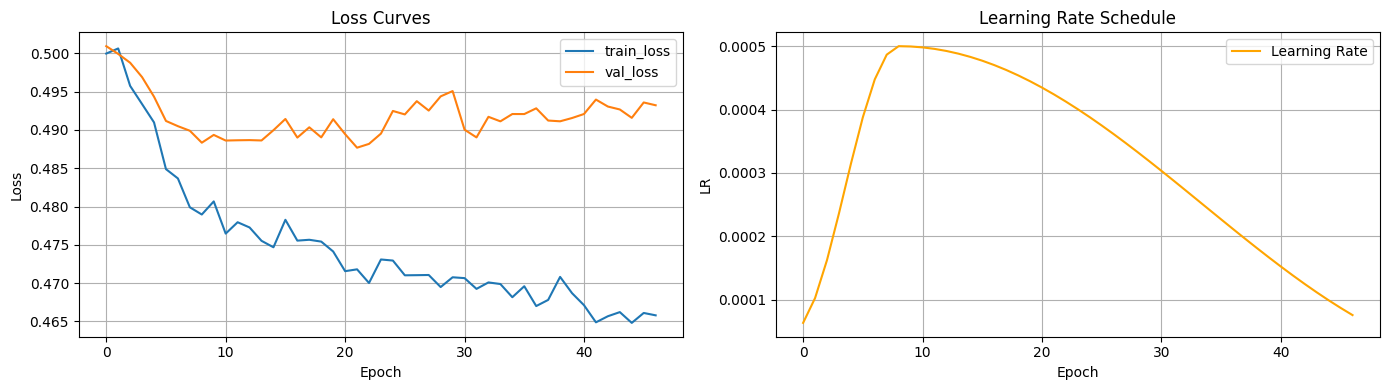

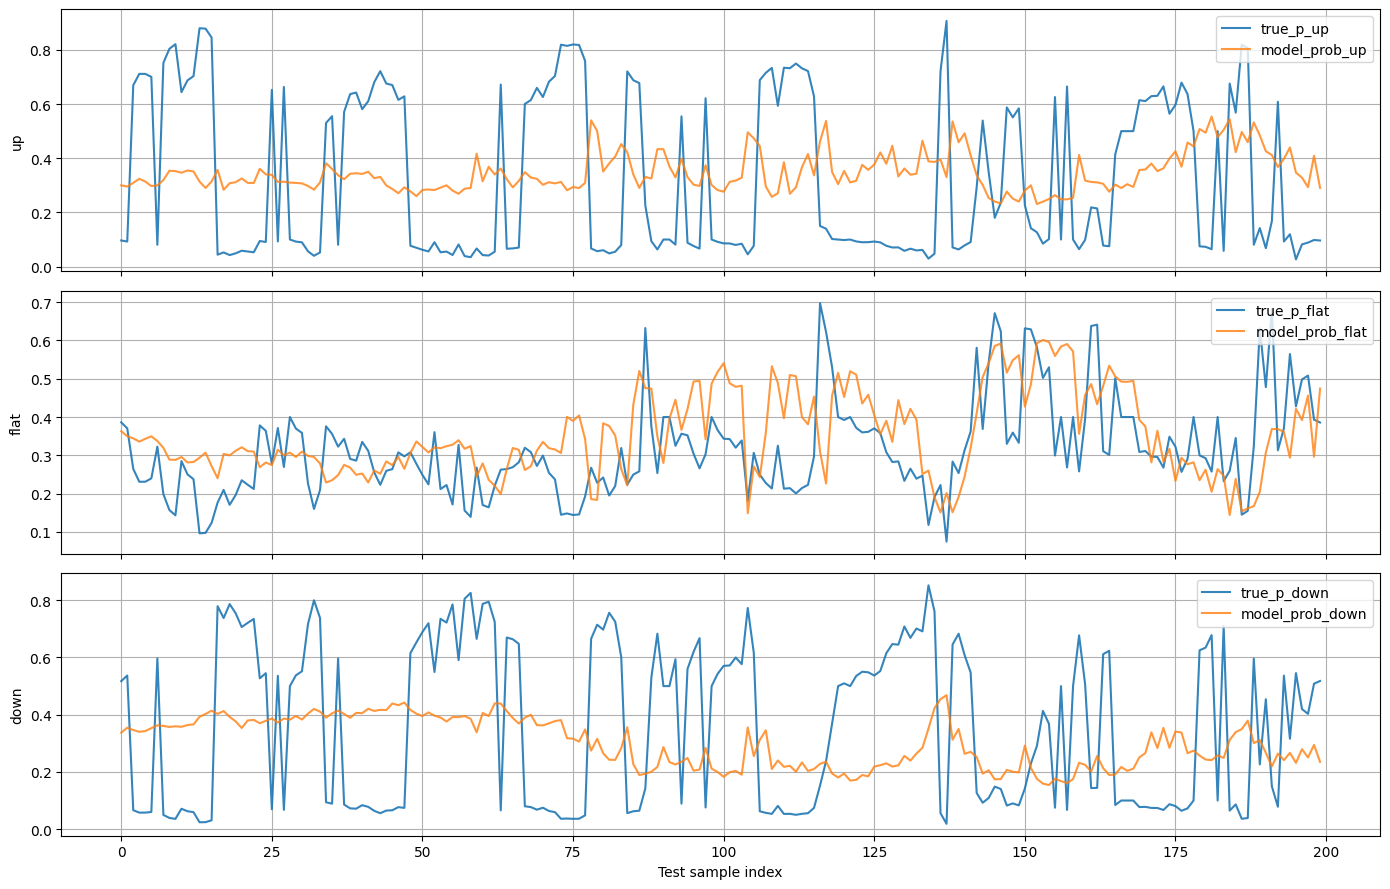

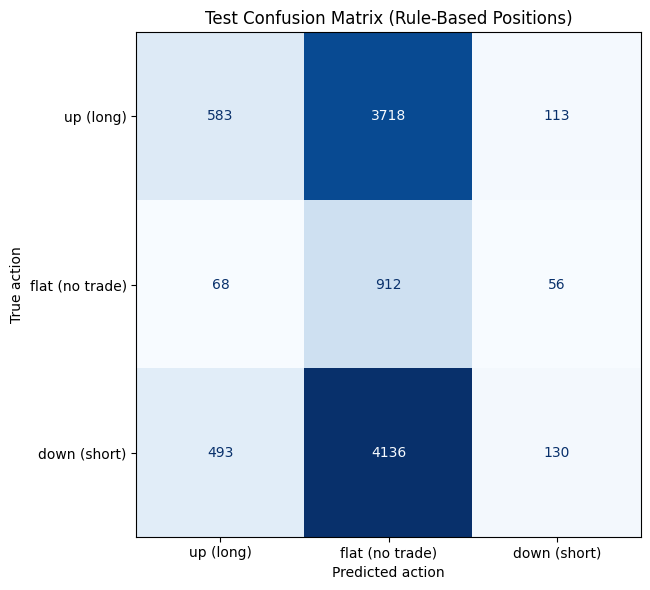

Predicted action distribution on test:
pred_trade_label
up      1144
flat    8766
down     299
Name: count, dtype: int64

True action distribution on test:
true_trade_label
up      4414
flat    1036
down    4759
Name: count, dtype: int64



,time,true_trade_label,prob_up,prob_flat,prob_down,pred_trade_label
0,2025-08-30 16:30:00,down,0.299937,0.362997,0.337065,flat
1,2025-08-30 17:00:00,down,0.295577,0.349760,0.354663,flat
2,2025-08-30 17:30:00,up,0.309174,0.344390,0.346436,flat
3,2025-08-30 18:00:00,up,0.324186,0.335632,0.340181,flat
4,2025-08-30 18:30:00,up,0.313930,0.343186,0.342883,flat
5,2025-08-30 19:00:00,up,0.297416,0.349615,0.352970,flat
6,2025-08-30 19:30:00,down,0.299681,0.337254,0.363064,flat
7,2025-08-30 20:00:00,up,0.319608,0.319507,0.360885,flat
8,2025-08-30 20:30:00,up,0.354013,0.288777,0.357211,flat
9,2025-08-30 21:00:00,up,0.352483,0.288044,0.359472,flat


In [69]:
# 8) Plots + confusion matrix (rule-based trade decisions)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history['train_loss'], label='train_loss')
if history.get('val_loss'):
    axes[0].plot(history['val_loss'], label='val_loss')
axes[0].set_title('Loss Curves')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history['lr'], label='Learning Rate', color='orange')
axes[1].set_title('Learning Rate Schedule')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('LR')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

plot_n = min(200, len(results))
fig, axes = plt.subplots(len(CLASS_NAMES), 1, figsize=(14, 3 * len(CLASS_NAMES)), sharex=True)
axes = np.atleast_1d(axes)

for ax, class_name in zip(axes, CLASS_NAMES):
    ax.plot(results[f'true_p_{class_name}'].iloc[:plot_n].to_numpy(), label=f'true_p_{class_name}', alpha=0.9)
    ax.plot(results[f'prob_{class_name}'].iloc[:plot_n].to_numpy(), label=f'model_prob_{class_name}', alpha=0.8)
    ax.set_ylabel(class_name)
    ax.grid(True)
    ax.legend(loc='upper right')

axes[-1].set_xlabel(f'{EVAL_SPLIT_DISPLAY} sample index')
plt.tight_layout()
plt.show()


def derive_trade_labels(p_buy, p_hold, p_sell):
    trade_labels = np.full(len(p_buy), 'flat', dtype=object)
    flat_gate = p_hold < TRADE_RULE_MAX_FLAT_PROB
    long_mask = flat_gate & (p_buy > TRADE_RULE_SIDE_RATIO * p_sell)
    short_mask = flat_gate & (~long_mask) & (p_sell > TRADE_RULE_SIDE_RATIO * p_buy)
    trade_labels[long_mask] = 'up'
    trade_labels[short_mask] = 'down'
    return trade_labels


results = results.copy()
results['true_trade_label'] = derive_trade_labels(
    p_buy=results['true_p_up'].to_numpy(),
    p_hold=results['true_p_flat'].to_numpy(),
    p_sell=results['true_p_down'].to_numpy(),
)
results['pred_trade_label'] = derive_trade_labels(
    p_buy=results['prob_up'].to_numpy(),
    p_hold=results['prob_flat'].to_numpy(),
    p_sell=results['prob_down'].to_numpy(),
)

cm = confusion_matrix(results['true_trade_label'], results['pred_trade_label'], labels=CLASS_NAMES)
display_labels = ['up (long)', 'flat (no trade)', 'down (short)']

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
ax.set_title(f'{EVAL_SPLIT_DISPLAY} Confusion Matrix (Rule-Based Positions)')
ax.set_xlabel('Predicted action')
ax.set_ylabel('True action')
plt.tight_layout()
plt.show()

print(f'Predicted action distribution on {EVAL_SPLIT_DISPLAY.lower()}:')
print(results['pred_trade_label'].value_counts().reindex(CLASS_NAMES, fill_value=0))

print()
print(f'True action distribution on {EVAL_SPLIT_DISPLAY.lower()}:')
print(results['true_trade_label'].value_counts().reindex(CLASS_NAMES, fill_value=0))

print()
display(results[['time', 'true_trade_label', 'prob_up', 'prob_flat', 'prob_down', 'pred_trade_label']].head(10))


In [70]:
# 9) Bias Check
import numpy as np


def safe_ratio(numerator, denominator):
    if np.isclose(denominator, 0.0):
        return np.inf
    return numerator / denominator


train_label_means = y_train.mean(axis=0)
print('Train set mean true labels [up, flat, down]:')
print(f'Up: {train_label_means[0]:.4f} | Flat: {train_label_means[1]:.4f} | Down: {train_label_means[2]:.4f}')

eval_true_means = y_true_probs.mean(axis=0)
print()
print(f'{EVAL_SPLIT_DISPLAY} set mean true labels [up, flat, down]:')
print(f'Up: {eval_true_means[0]:.4f} | Flat: {eval_true_means[1]:.4f} | Down: {eval_true_means[2]:.4f}')

eval_pred_means = y_probs.mean(axis=0)
print()
print(f'{EVAL_SPLIT_DISPLAY} set mean predicted labels [up, flat, down]:')
print(f'Up: {eval_pred_means[0]:.4f} | Flat: {eval_pred_means[1]:.4f} | Down: {eval_pred_means[2]:.4f}')

print()
print(f'Train UP/DOWN ratio: {safe_ratio(train_label_means[0], train_label_means[2]):.2f}')
print(f'Model {EVAL_SPLIT_DISPLAY} UP/DOWN ratio: {safe_ratio(eval_pred_means[0], eval_pred_means[2]):.2f}')


Train set mean true labels [up, flat, down]:
Up: 0.3287 | Flat: 0.3474 | Down: 0.3239

Test set mean true labels [up, flat, down]:
Up: 0.3167 | Flat: 0.3462 | Down: 0.3371

Test set mean predicted labels [up, flat, down]:
Up: 0.3588 | Flat: 0.3453 | Down: 0.2960

Train UP/DOWN ratio: 1.01
Model Test UP/DOWN ratio: 1.21
